<a href="https://colab.research.google.com/github/tylerjohnbecker/Nonlinear_and_Data_Driven_Estimation/blob/main/BouncingBall.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [607]:
import numpy as np
import matplotlib.pyplot as plt
import pandas
from scipy.integrate import odeint

In [608]:
import sys
import requests
import importlib

def import_local_or_github(package_name, function_name=None, directory=None, giturl=None):
    # Import functions directly from github
    # Important: note that we use raw.githubusercontent.com, not github.com

    try: # to find the file locally
        if directory is not None:
            if directory not in sys.path:
                sys.path.append(directory)

        package = importlib.import_module(package_name)
        if function_name is not None:
            function = getattr(package, function_name)
            return function
        else:
            return package

    except: # get the file from github
        if giturl is None:
            giturl = 'https://raw.githubusercontent.com/florisvb/Nonlinear_and_Data_Driven_Estimation/main/Utility/' + str(package_name) + '.py'

        r = requests.get(giturl)
        print('Fetching from: ')
        print(r)

        # Store the file to the colab working directory
        with open(package_name+'.py', 'w') as f:
            f.write(r.text)
        f.close()

        # import the function we want from that file
        package = importlib.import_module(package_name)
        if function_name is not None:
            function = getattr(package , function_name)
            return function
        else:
            return package

plot_tme = import_local_or_github('plot_utility', 'plot_tme', directory='../Utility')

In [609]:
try:
    import casadi
except:
    !pip install casadi
    import casadi

try:
    import do_mpc
except:
    !pip install do_mpc
    import do_mpc

try:
    import pybounds
except:
    !pip install pybounds
    import pybounds

# Parameters for the Linear System (Unknowns lead to nonlinearity)

In [610]:
m = 1
r = .5
e = .6
mu = .4
delta_t = .2
Im = .02
g=-9.81

# In-Air Dynamics for the Bouncing Ball

In [611]:
def f_in_air(x_vec, u_vec, m=m, g=g, Im=Im, r=r, e=e, mu=mu):
    """
    Continuous time dynamics function for the system shown in the equation.

    Parameters:
    x_vec : array-like, shape (7,)
        State vector [θ, θ̇, x, ẋ, z, ż, k]
    u_vec : array-like, shape (2,)
        Control vector [j1, j2]
    m : float, shape (1,)
        mass of the ball
    g : float, shape (1,)
        acceleration due to gravity
    Im : float, shape (1,)
        Inertia for the ball
    r : float, shape (1,)
        radius of the ball
    e : float, shape (1,)
        coefficient of restitution
    mu : float, shape (1,)
        coefficient of friction

    Returns:
    x_dot : numpy array, shape (7,)
        Time derivative of state vector
    """

    # Extract state variables
    x = x_vec[0]
    x_dot = x_vec[1]
    z = x_vec[2]
    z_dot = x_vec[3]
    theta = x_vec[4]
    theta_dot = x_vec[5]

    # Extract control inputs
    f_x = u_vec[0]
    f_z = u_vec[1]
    tor = u_vec[2]

    # f0 component: drift dynamics (no controls)
    f0_contribution = np.array([ x_dot,
                                 0,
                                 z_dot,
                                 g,
                                 theta_dot,
                                 0])

    # f1 component: multiplied by control u1
    f1_contribution = f_x * np.array([0,
                                     1 / m,
                                     0,
                                     0,
                                     0,
                                     0])

    # f2 component: multiplied by control u2
    f2_contribution = f_z * np.array([0,
                                     0,
                                     0,
                                     1 / m ,
                                     0,
                                     0])

    # f3 component: multiplied by control u3
    f3_contribution = tor * np.array([0,
                                     0,
                                     0,
                                     0,
                                     0,
                                     1 / Im])

    # combined dynamics
    x_dot_vec = f0_contribution + f1_contribution + f2_contribution + f3_contribution

    return x_dot_vec

# Impact Dynamics of the Ball

In [631]:
# only compute these after it first impacts?
first = True
goal_z_dot = 0

def f_impact(x_vec, u_vec, m=m, g=g, Im=Im, r=r, e=e, mu=mu):
    """
    Continuous time dynamics function for the system shown in the equation.

    Parameters:
    x_vec : array-like, shape (7,)
        State vector [θ, θ̇, x, ẋ, z, ż, k]
    u_vec : array-like, shape (2,)
        Control vector [j1, j2]
    m : float, shape (1,)
        mass of the ball
    g : float, shape (1,)
        acceleration due to gravity
    Im : float, shape (1,)
        Inertia for the ball
    r : float, shape (1,)
        radius of the ball
    e : float, shape (1,)
        coefficient of restitution
    mu : float, shape (1,)
        coefficient of friction

    Returns:
    x_dot : numpy array, shape (7,)
        Time derivative of state vector
    """

    global first, goal_z_dot

    # Extract state variables
    x = x_vec[0]
    x_dot = x_vec[1]
    z = x_vec[2]
    z_dot = x_vec[3]
    theta = x_vec[4]
    theta_dot = x_vec[5]

    # Extract control inputs
    f_x = u_vec[0]
    f_z = u_vec[1]
    tor = u_vec[2]

    if z <= r + .1 and first:
        goal_z_dot = max(0, - z_dot)
        first = False

        if goal_z_dot < 0:
            print(goal_z_dot)
    elif z > r + .1:
        first = True
        return np.array([0, 0, 0, 0, 0, 0])

    N = m * g

    bot_x_dot = - theta_dot * r

    friction_x = - np.sign(x_dot) * np.abs( mu * N )
    friction_rot = - np.sign(bot_x_dot) * np.abs( mu * N )

    x_friction = ( friction_x + friction_rot )

    bounce_z = (goal_z_dot - z_dot) / delta_t

    # f0 component: drift dynamics (no controls)
    f0_contribution = np.array([ x_dot,
                                 x_friction / m,
                                 z_dot,
                                 bounce_z,
                                 theta_dot,
                                 - r * friction_rot / Im ])

    # f1 component: multiplied by control u1
    f1_contribution = f_x * np.array([0,
                                     1 / m,
                                     0,
                                     0,
                                     0,
                                     0])

    # f2 component: multiplied by control u2
    f2_contribution = f_z * np.array([0,
                                     0,
                                     0,
                                     1 / m,
                                     0,
                                     0])

    # f3 component: multiplied by control u3
    f3_contribution = tor * np.array([0,
                                     0,
                                     0,
                                     0,
                                     0,
                                     1 / Im])

    # combined dynamics
    x_dot_vec = f0_contribution + f1_contribution + f2_contribution + f3_contribution

    # print(f'init: {goal_z_dot} => cur: {z_dot} | update: {bounce_z} | f0: {f0_contribution[3]} | f2: {f2_contribution[3]}')

    return x_dot_vec

In [632]:
def sigm(input):
    return 1 / (1 + np.exp(-input))

In [633]:
def f_sigm_combined(x_vec, u_vec, m=m, g=g, Im=Im, r=r, e=e, mu=mu):
    z = x_vec[2]

    # I want the behavior that the sigmoid will start close to the ground
    alpha = sigm( 15 * z - 7.5 )

    return alpha * f_in_air(x_vec, u_vec) + (1 - alpha) * f_impact(x_vec, u_vec)

# ODE wrapper for the In-Air Dynamics

In [634]:
def f_ode(x_vec, tsim, u_func, f):
    '''
    Wrap dynamics function so it can be used with odeint.

    Parameters:
    x_vec : array-like, shape (7,)
        State vector
    tsim : float
        Current time step
    u_func: function
        Control function
    f: function
        Continuous time dynamics function

    Returns:
    x_dot_vec : numpy array, shape (7,)
        Time derivative of state vector
    '''
    u_vec = u_func(x_vec, tsim)
    x_dot_vec = f_sigm_combined(x_vec, u_vec)
    return x_dot_vec

# Basic Ball Bouncing Controls
When the ball is above 3 meters we accelerate it downwards to ensure that it continues bouncing

In [641]:
def u_func(x_vec, tsim, m=m, g=g, r=r, Im=Im, e=e, mu=mu):
    '''
    Simple controller that moves the drone right, so I can observe it bouncing.
    '''
    x_dot_desired = 1
    x_dot = x_vec[1]

    err_x = max( 0, x_dot_desired - x_dot )

    ctrl_x = 10 * err_x

    theta_dot_desired = -1
    theta_dot = x_vec[5]

    err_theta = theta_dot_desired - theta_dot

    ctrl_theta = 10 * err_theta

    z_dot_desired = -5
    z_dot = x_vec[3]

    err_z = min( 0, z_dot_desired - z_dot )
    ctrl_z = 10 * err_z

    if x_vec[2] > 1:
       return [0, ctrl_z, 0]

    return [0, 0, 0]

In [642]:
delta_t = .05
tsim = np.arange(0, 8.0, step=delta_t)

In [643]:
x0 = np.array([0, 1, 4.0, 0, 0, 0])

# Simulate the dynamics using ODE int

In [644]:
initial_state = x0

result = odeint(f_ode, x0, tsim, args=(u_func, f_sigm_combined) )

/tmp/ipython-input-3768798501.py:3: ODEintWarning: Excess work done on this call (perhaps wrong Dfun type). Run with full_output = 1 to get quantitative information.
  result = odeint(f_ode, x0, tsim, args=(u_func, f_sigm_combined) )


Text(0, 0.5, 'theta_dot')

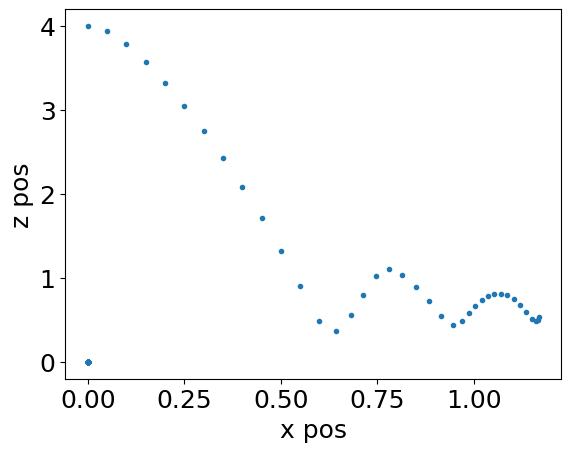

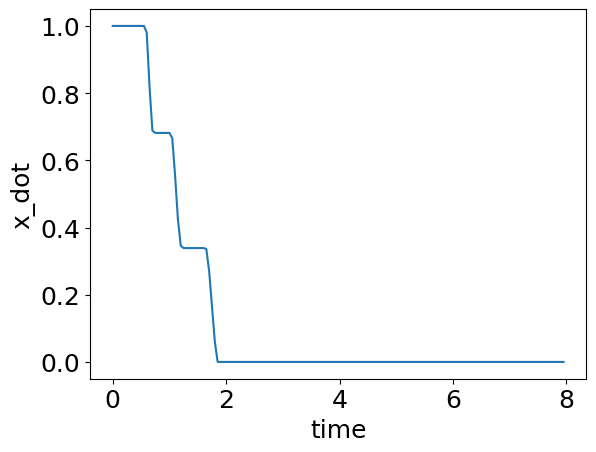

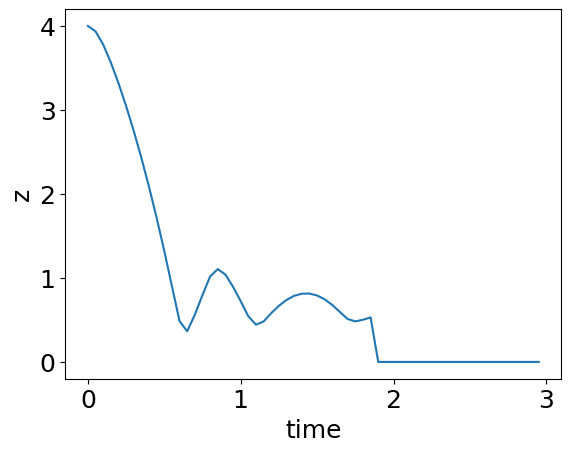

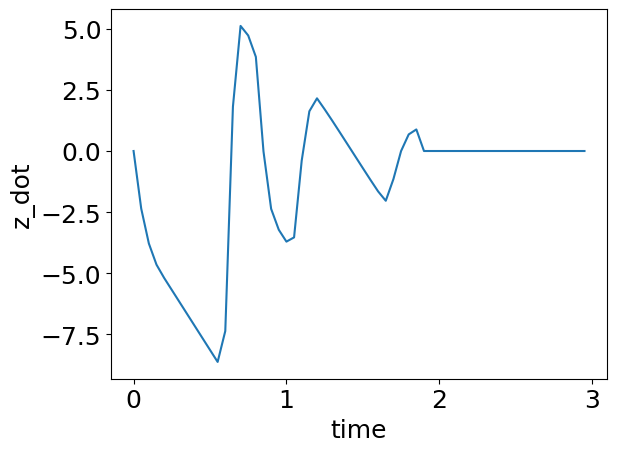

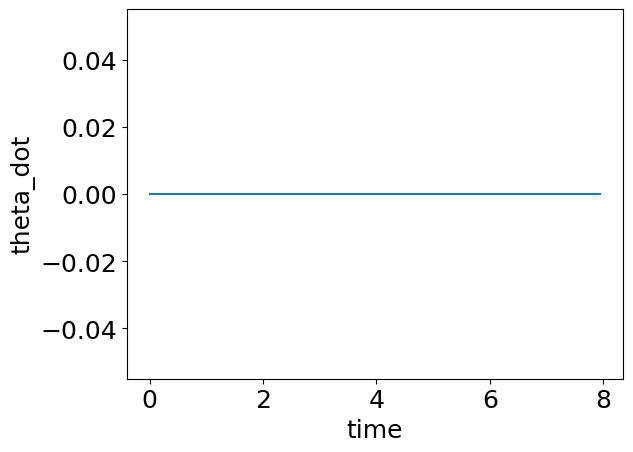

In [645]:
sol = np.array(result)

fig = plt.figure()
ax = fig.add_subplot(111)
ax.plot(sol[:, 0], sol[:, 2], '.')
ax.set_xlabel('x pos')
ax.set_ylabel('z pos')

fig3 = plt.figure()
ax3 = fig3.add_subplot(111)
ax3.plot(tsim, sol[:,1])
ax3.set_xlabel('time')
ax3.set_ylabel('x_dot')
fig2 = plt.figure()
ax2 = fig2.add_subplot(111)
ax2.plot(tsim[:-100], sol[:-100,2])
ax2.set_xlabel('time')
ax2.set_ylabel('z')
fig3 = plt.figure()
ax3 = fig3.add_subplot(111)
ax3.plot(tsim[:-100], sol[:-100,3])
ax3.set_xlabel('time')
ax3.set_ylabel('z_dot')
fig3 = plt.figure()
ax3 = fig3.add_subplot(111)
ax3.plot(tsim, sol[:,5])
ax3.set_xlabel('time')
ax3.set_ylabel('theta_dot')

In [640]:
def h(x_vec, u_vec):
    noise = np.random.normal(0, 1, 3)
    return np.array([x_vec[0] + noise[0], x_vec[2] + noise[1], x_vec[5] + noise[2]])